## Part 1: Data Loading and Exploration

Our goal is to create a neural network that predicts medical costs given demographic information: age, sex, BMI, number of dependents, smoking status, and residential area. A medical bill is a continuous variable, so this is a regression problem. The first step is data loading and exploration: import the dataset, check data types, check for missing values, and check for duplicate rows.

In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json
import os

from scipy.stats import randint

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


We can see here that the data types are correct and make sense for each variable. Also, we don't have any missing values. 

Let's see what the distribution of the 'charges' variable looks like (this is our target variable).

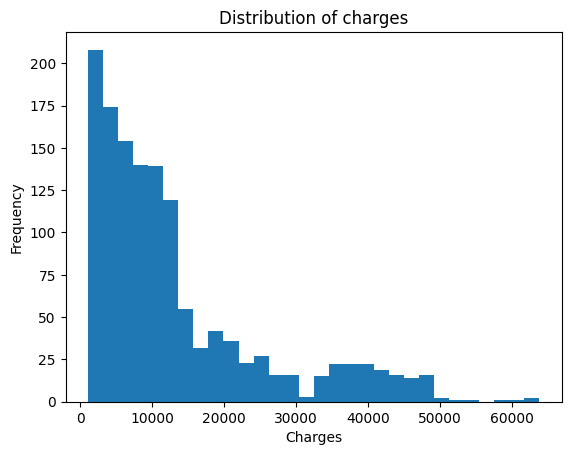

In [4]:
# Distribution of 'charges'
plt.figure()
plt.hist(df['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of charges')
plt.show()

We can see here that most values for 'charges' fall in the range 0 - 10,000. 

Next, let's check for duplicate rows.

In [5]:
# Check for duplicate rows
print(df.duplicated().sum())

1


We can see here that we have 1 duplicate row. Let's get rid of it.

In [6]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB
None


The duplicate row has been dropped successfully. Next, let's view a sample of the dataset (first 5 rows).

In [8]:
# Print a sample of the dataset
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


The 'charges' value is our target variable. We have 3 numerical features: 'age', 'bmi', and 'children.' Also, we have 3 categorical features: 'sex', 'smoker', and 'region.'

## Part 2: Data Preprocessing

Let's prepare the data for neural network training.

## Feature Engineering: OHE

We need to convert the categorical features to numbers. We can accomplish this via one-hot encoding (OHE), which is shown below.

In [9]:
# One-hot encoding
df_ohe = pd.get_dummies(df, drop_first = True)
print(df_ohe.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   uint8  
 5   smoker_yes        1337 non-null   uint8  
 6   region_northwest  1337 non-null   uint8  
 7   region_southeast  1337 non-null   uint8  
 8   region_southwest  1337 non-null   uint8  
dtypes: float64(2), int64(2), uint8(5)
memory usage: 48.4 KB
None


We can see here that we implemented OHE successfully. Let's see what the first 5 rows of the dataset look like now.

In [10]:
print(df_ohe.head())

   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


We now have 8 numerical features: 'age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', and 'region_southwest.' 

## Split the Data

We will perform a 60-20-20 split of the data below: 60% training, 20% validation, and 20% testing. We are choosing these percentages because:

* 60% training gives us enough data for model fitting.
* 20% validation allows fair hyperparameter tuning and model comparison.
* 20% testing is large enough to provide a stable final accuracy estimate.

In [11]:
# Features and target
features = df_ohe.drop('charges', axis=1)
target = df_ohe['charges']

In [12]:
# Step 1: split off the test set (20%)
features_temp, features_test, target_temp, target_test = train_test_split(
    features,
    target,
    test_size = 0.20,
    random_state = 42
)

# Step 2: split remaining data into train (60%) and validation (20%)
# 0.25 * 0.80 = 0.20 of original data
features_train, features_val, target_train, target_val = train_test_split(
    features_temp,
    target_temp,
    test_size = 0.25,
    random_state = 42
)

## Normalization

We will scale the features 'age', 'bmi', and 'children' to similar ranges below. We will also scale the target 'charges.'

The math involved in normalization is given as:

$$\text{normalized value} = \text{(original value - min)}/\text{(max - min)}$$

Let's normalize the features 'age', 'bmi', and 'children.'

In [13]:
# Make copies
features_train_norm = features_train.copy()
features_val_norm = features_val.copy()
features_test_norm = features_test.copy()

In [14]:
# Store columns to be normalized in the variable cols
# Store new column names in the variable norm_cols
cols = ['age', 'bmi', 'children']
norm_cols = [f'{c}_norm' for c in cols]

In [15]:
# Compute min and max from training data
train_min = features_train[cols].min()
train_max = features_train[cols].max()

In [16]:
# Normalize
# Training set
features_train_norm[norm_cols] = (features_train[cols] - train_min) / (train_max - train_min)

# Validation set
features_val_norm[norm_cols] = (features_val[cols] - train_min) / (train_max - train_min)

# Test set
features_test_norm[norm_cols] = (features_test[cols] - train_min) / (train_max - train_min)

In [17]:
# Drop original columns 'age', 'bmi', and 'children'
features_train_norm.drop(columns=cols, inplace=True)
features_val_norm.drop(columns=cols, inplace=True)
features_test_norm.drop(columns=cols, inplace=True)

In [18]:
# Inspect new dataframes
print('NORMALIZED TRAINING SET:')
print(features_train_norm.head())
print('')
print('NORMALIZED VALIDATION SET:')
print(features_val_norm.head())
print('')
print('NORMALIZED TEST SET:')
print(features_test_norm.head())

NORMALIZED TRAINING SET:
      sex_male  smoker_yes  region_northwest  region_southeast  \
1251         1           1                 0                 0   
480          1           0                 1                 0   
693          0           0                 0                 0   
545          1           1                 1                 0   
1002         1           0                 0                 0   

      region_southwest  age_norm  bmi_norm  children_norm  
1251                 1  0.043478  0.288724            0.0  
480                  0  0.978261  0.674928            0.6  
693                  1  0.195652  0.495250            0.2  
545                  0  0.673913  0.248520            0.4  
1002                 1  0.652174  0.352058            0.0  

NORMALIZED VALIDATION SET:
     sex_male  smoker_yes  region_northwest  region_southeast  \
603         0           1                 1                 0   
716         1           0                 1                 

Let's also normalize the target 'charges.'

In [19]:
# Make copies
target_train_norm = target_train.copy()
target_val_norm = target_val.copy()
target_test_norm = target_test.copy()

In [20]:
# Compute min and max from training data
target_min = target_train.min()
target_max = target_train.max()

In [21]:
# Normalize
# Training set
target_train_norm = (target_train - target_min) / (target_max - target_min)

# Validation set
target_val_norm = (target_val - target_min) / (target_max - target_min)

# Test set
target_test_norm = (target_test - target_min) / (target_max - target_min)

In [22]:
# Inspect new dataframes
print('NORMALIZED TRAINING SET:')
print(target_train_norm.head())
print('')
print('NORMALIZED VALIDATION SET:')
print(target_val_norm.head())
print('')
print('NORMALIZED TEST SET:')
print(target_test_norm.head())

NORMALIZED TRAINING SET:
1251    0.245823
480     0.234799
693     0.039956
545     0.369042
1002    0.327151
Name: charges, dtype: float64

NORMALIZED VALIDATION SET:
603    0.265932
716    0.195063
608    0.620123
285    0.107697
509    0.168102
Name: charges, dtype: float64

NORMALIZED TEST SET:
899     0.123098
1063    0.074620
1255    0.167800
298     0.612069
237     0.054356
Name: charges, dtype: float64


## Part 3: Build the Neural Network

We will create a neural network with 2 hidden layers: 128 neurons in the first layer and 64 neurons in the second layer. We will implement batch normalization, L2 regularization (0.001), and dropout (0.3). The values for these hyperparameters were used in the lessons, so using those same values here is a good starting point for us. 

In [23]:
# Build the model
model = Sequential([
    Dense(128, activation = 'relu', kernel_regularizer = l2(0.001), input_shape = (8, )),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation = 'relu', kernel_regularizer = l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation = 'linear')
])

2026-03-02 16:34:57.918537: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [24]:
# Compile the model
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

## Part 4: Train the Model

We will use the training set ('features_train_norm' and 'target_train_norm') to train the model below. We will also use the validation set ('features_val_norm' and 'target_val_norm') to evaluate the model's performance.

In [25]:
# Train the model
history = model.fit(
    features_train_norm, target_train_norm,
    validation_data = (features_val_norm, target_val_norm),
    epochs = 100,
    batch_size = 32
)

Epoch 1/100
26/26 [==============================] - 1s 7ms/step - loss: 2.0964 - mae: 1.0797 - val_loss: 0.1395 - val_mae: 0.1328
Epoch 2/100
26/26 [==============================] - 0s 2ms/step - loss: 1.3863 - mae: 0.8798 - val_loss: 0.1373 - val_mae: 0.1454
Epoch 3/100
26/26 [==============================] - 0s 2ms/step - loss: 1.0974 - mae: 0.7786 - val_loss: 0.1404 - val_mae: 0.1689
Epoch 4/100
26/26 [==============================] - 0s 2ms/step - loss: 1.0098 - mae: 0.7594 - val_loss: 0.1360 - val_mae: 0.1605
Epoch 5/100
26/26 [==============================] - 0s 2ms/step - loss: 0.8197 - mae: 0.6684 - val_loss: 0.1397 - val_mae: 0.1759
Epoch 6/100
26/26 [==============================] - 0s 2ms/step - loss: 0.6934 - mae: 0.6084 - val_loss: 0.1383 - val_mae: 0.1730
Epoch 7/100
26/26 [==============================] - 0s 2ms/step - loss: 0.6306 - mae: 0.5828 - val_loss: 0.1357 - val_mae: 0.1628
Epoch 8/100
26/26 [==============================] - 0s 2ms/step - loss: 0.5763 - m

We can see here that all 4 metrics (training loss, training MAE, validation loss, and validation MAE) have decreased during training. So the neural network is learning effectively. Let's use the test set to evaluate the model's performance.

## Part 5: Evaluate the Model

We use the test set ('feature_test_norm' and 'target_test_norm') to evaluate the model below.

In [26]:
# Evaluate the model on the test set
test_loss, test_mae = model.evaluate(
    features_test_norm,
    target_test_norm,
    verbose=0
)

print(f"Test MSE (loss): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

Test MSE (loss): 0.0565
Test MAE: 0.0562


The training loss, training MAE, validation loss, validation MAE, test loss, and test MAE are all low (less than 0.1). So the model is performing well. For further evaluation, let's make predictions on a few test examples.

In [27]:
# Select 5 test examples
X_sample = features_test_norm[:5]
y_sample = target_test_norm[:5].values.reshape(-1)

In [28]:
# Predict normalized charges
y_pred = model.predict(X_sample).reshape(-1)

In [29]:
# Create a table to organize results
columns = [
    "sex_male",
    "smoker_yes",
    "region_northwest",
    "region_southeast",
    "region_southwest",
    "age_norm",
    "bmi_norm",
    "children_norm"
]

results = pd.DataFrame(X_sample, columns=columns)

results["true_charges_norm"] = y_sample
results["pred_charges_norm"] = y_pred
results["absolute_error"] = np.abs(y_sample - y_pred)

results

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_norm,bmi_norm,children_norm,true_charges_norm,pred_charges_norm,absolute_error
899,1,0,0,0,0,0.673913,0.156960,0.0,0.123098,0.139355,0.016257
1063,0,0,0,0,1,0.239130,0.241911,0.8,0.074620,0.090976,0.016355
1255,0,0,1,0,0,0.717391,0.538896,0.6,0.167800,0.188718,0.020917
298,1,1,1,0,0,0.282609,0.483960,0.6,0.612069,0.431623,0.180445
237,1,0,0,1,0,0.282609,0.594107,0.4,0.054356,0.069453,0.015097


In [30]:
# Calculate MSE and MAE
#MSE
mse_sample = mean_squared_error(y_sample, y_pred)

#MAE
mae_sample = mean_absolute_error(y_sample, y_pred)

print(f"MSE (5 examples): {mse_sample:.6f}")
print(f"MAE (5 examples): {mae_sample:.6f}")

MSE (5 examples): 0.006752
MAE (5 examples): 0.049814


The values for MSE and MAE are both low. So the model is performing well on the test examples.

## Part 6: Visualization and Analysis

We are interested in the training history, predictions vs. actual values, and the model architecture. So we will create visualizations below. 

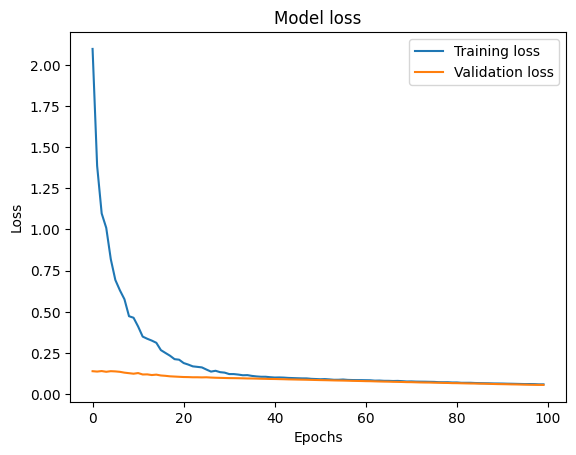

In [31]:
# Training history
plt.plot(history.history['loss'], label = 'Training loss')
plt.plot(history.history['val_loss'], label = 'Validation loss')
plt.title('Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

The training loss consistently decreases over the 100 epochs. The validation loss also consistently decreases. This means that the model was trained successfully in a stable manner.

In [32]:
# Predictions vs. actual
# Predict normalized charges for the full test set
y_test_pred = model.predict(features_test_norm).reshape(-1)
y_test_true = target_test_norm.values.reshape(-1)

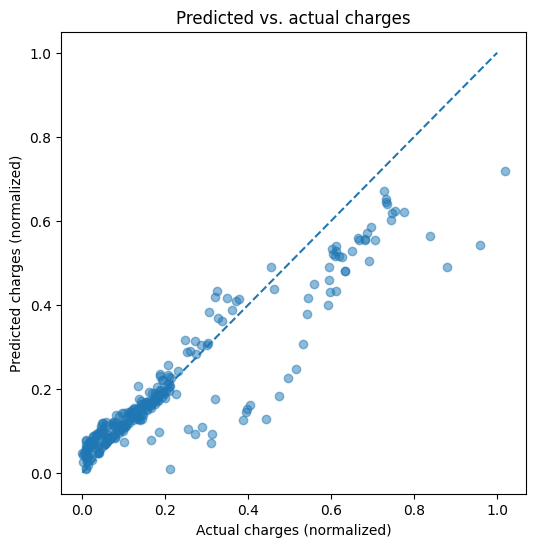

In [33]:
# Create figure
plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(y_test_true, y_test_pred, alpha=0.5)

# Diagonal reference line (perfect predictions)
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("Actual charges (normalized)")
plt.ylabel("Predicted charges (normalized)")
plt.title("Predicted vs. actual charges")

plt.show()

The points are close to the diagonal line ($y = x$). So the model is performing well. Here is the model architecture.

In [34]:
# Model architecture
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               1152      
                                                                 
 batch_normalization (BatchN  (None, 128)              512       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 batch_normalization_1 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 64)                0

We can see here that the model has 10,241 total parameters. Here is the final model configuration.

In [35]:
# Final model configuration
config = {
    'architecture': '128-64-1',
    'dropout': 0.3,
    'l2': 0.001,
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': min(history.history['val_loss'])
}

config

{'architecture': '128-64-1',
 'dropout': 0.3,
 'l2': 0.001,
 'epochs_trained': 100,
 'best_val_loss': 0.05621807277202606}

We also want to know what features are most important for predicting medical bills. So we find out with the code below.

In [36]:
# Feature importances
feature_names = [
    "sex_male",
    "smoker_yes",
    "region_northwest",
    "region_southeast",
    "region_southwest",
    "age_norm",
    "bmi_norm",
    "children_norm"
]

# Baseline error
y_pred = model.predict(features_test_norm).reshape(-1)
baseline_mse = mean_squared_error(target_test_norm, y_pred)

importances = []

for feature in feature_names:
    X_permuted = features_test_norm.copy()

    # Shuffle one column
    X_permuted[feature] = np.random.permutation(X_permuted[feature].values)

    y_perm_pred = model.predict(X_permuted).reshape(-1)
    perm_mse = mean_squared_error(target_test_norm, y_perm_pred)

    importances.append(perm_mse - baseline_mse)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
1,smoker_yes,0.055973
6,bmi_norm,0.008296
5,age_norm,0.006817
3,region_southeast,0.000333
0,sex_male,0.000298
7,children_norm,0.000283
2,region_northwest,0.000080
4,region_southwest,0.000027


## Part 7: Conclusion

We successfully created a neural network, for predicting medical bills, in several steps. To begin, we performed data loading and exploration. We imported the dataset, checked data types, checked for missing values, and checked for duplicate rows. We also visualized the distribution of the target variable 'charges.' We found that most values lie in the range 0 - 10,000.

For data preprocessing, we performed one-hot encoding to change the categorical variables ('sex', 'smoker', and 'region') into numeric variables. Once we had only numeric features, we decided to squash values between 0 and 1 (normalization). We normalized the features 'age', 'bmi', and 'children.' We also normalized the target 'charges'. So both the input and the output of the neural network were normalized values between 0 and 1. The result of this normalization was that the model trained smoothly (in a stable manner).

We created a neural network with 2 hidden layers: 128 neurons in the first layer and 64 neurons in the second layer. We implemented batch normalization, L2 regularization (0.001), and dropout (0.3). These values worked well in the lessons and they also worked well here. So we didn't need to do any experimentation with different architectures or hyperparameters.

The final test set performance was good. We had test MSE loss = 0.0565 and test MAE = 0.0562. These values are both low, so the model is well-balanced. Here is the best model configuration:

In [37]:
# Best model configuration
config

{'architecture': '128-64-1',
 'dropout': 0.3,
 'l2': 0.001,
 'epochs_trained': 100,
 'best_val_loss': 0.05621807277202606}

The top 3 features with the most importance for predicting insurance costs are smoker status, BMI, and age. So this is an interesting insight. Another insight is to ask: if we had more time, what would we do differently? We could experiment with different model architecture, and/or set different values for the hyperparameters. To make improvements on the model, we would need to check for signs of underfitting/overfitting. If we detected underfitting, we would:

1. Increase model complexity
2. Train for more epochs
3. Add more relevant features
4. Check for data preprocessing issues

If we detected overfitting, we would:

1. Get more training data
2. Reduce model complexity
3. Use early stopping
4. Use dropout